# Ecuaciones de la Mecánica Cuántica

Estudiaremos el caso del Pozo Cuadrado Finito
$$V(x) = \begin{cases} -V_0, \quad|x|\leq R\\
0, \qquad|x| > R \end{cases}$$
Con la energía $$E = -E_b <0$$
Usando condiciones de frontera se obtienen:
- Estados pares: 
$$\sqrt{V_0 - E_B}\ tan(\sqrt{V_0 - E_B}) = \sqrt{E_B}$$
- Estados impares
$$-\sqrt{V_0 - E_B}\ cot(\sqrt{V_0 - E_B}) = \sqrt{E_B}$$
Para resolverlo utilizamos el método de bisección para encontrar las raíces.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

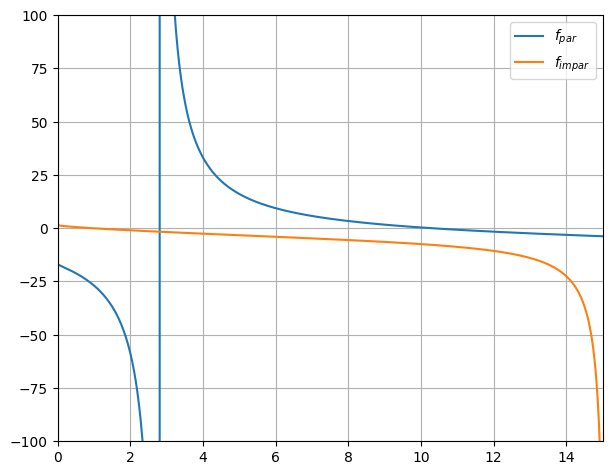

In [3]:
V0 = 25
Eb = np.linspace(0, 15, 1000)
fpar = np.sqrt(V0 - Eb) * np.tan(np.sqrt(V0 - Eb)) - np.sqrt(Eb)
fimpar = - np.sqrt(V0 - Eb) * (1 / np.tan(np.sqrt(V0 - Eb))) - np.sqrt(Eb)

#plt.plot(Eb, f, label = r'f')
plt.plot(Eb, fpar, label = r'$f_{par}$')
plt.plot(Eb, fimpar, label = r'$f_{impar}$')
plt.tight_layout()
plt.grid()
plt.legend()
plt.ylim(-100, 100)
plt.xlim(0, 15)
plt.show()

[ 2.7933901 10.2738462 22.5325989 23.2932145]
[ 0.9282679  15.1303956  18.26213863]


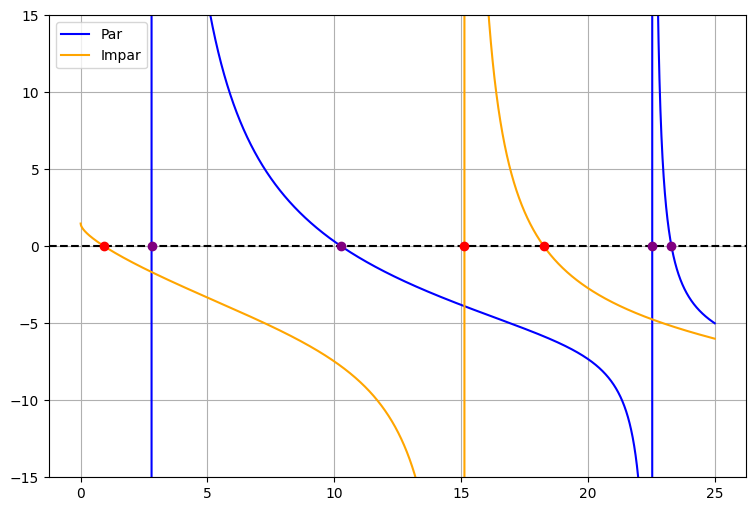

In [4]:
def f_even(E):
    return np.sqrt(V0 - E) * np.tan(np.sqrt(V0 - E)) - np.sqrt(E)

def f_odd(E):
    return - np.sqrt(V0 - E) * (1 / np.tan(np.sqrt(V0 - E))) - np.sqrt(E)

def Bisection(fun, Xminus, Xplus, Nmax = 100, eps = 1e-8):
    
    for it in range(Nmax):
        x = (Xplus + Xminus) / 2.0

        if (fun(Xplus) * fun(x) > 0.0):
            Xplus = x
        else:
            Xminus = x
        
        if (abs(fun(x)) < eps):
            break
    
    return x

N = 10000

E = np.linspace(1.0e-5, V0 - 1e-5, N)

Feven = np.zeros(N)
Fodd = np.zeros(N)

for i in range(N):
    Feven[i] = f_even(E[i])
    Fodd[i] = f_odd(E[i])

roots_even = np.array([])
roots_odd = np.array([])

for i in range(N - 1):
    
    if np.isfinite(Feven[i]) and np.isfinite(Feven[i + 1]):

        if Feven[i] * Feven[i + 1] < 0:

            r = Bisection(f_even, E[i], E[i + 1])

            roots_even = np.append(roots_even, r)

    if np.isfinite(Fodd[i]) and np.isfinite(Fodd[i + 1]):

        if Fodd[i] * Fodd[i + 1] < 0:

            r = Bisection(f_odd, E[i], E[i + 1])

            roots_odd = np.append(roots_odd, r)

print(roots_even)
print(roots_odd)
plt.figure(figsize = (9, 6))

plt.plot(E, Feven, label = 'Par', color = 'blue')
plt.plot(E, Fodd, label = 'Impar', color = 'orange')
plt.axhline(0, color = 'k', linestyle = '--')
plt.plot(roots_even, np.zeros(len(roots_even)), 'o', color = 'purple')
plt.plot(roots_odd, np.zeros(len(roots_odd)), 'o',  color = 'red')
plt.legend()
plt.ylim(-15,15)
plt.grid()
plt.show()

# Método  de Disparo (Shooting Method)
$$\frac{-\hbar^2}{2m}\frac{d^2\psi}{dt^2} + V(x)\psi = \kappa ^2 \psi$$
La estrategia es:
- Elegir una energía de prueba E
- Resolver la ecuaciónd de Shrödinger mediante RK4
- Verificar si la función de onda satisface las condiciones de frontera..
- Ajustar el valor de E
- Repetir el prcedimiento hasta obtener una solución normalizable.

Tenemos que energías arbitrarias producen que la función diverja para $x\rightarrow \pm \infty$. Solamente valores específicos de energía mantienen a la función cuadrado - normalizable. A estos valores se les conoce como los autovalores del sistema.

# Pozo cuadrado Finito
Propondremos un algoritmo para la búsqueda de estados ligados a través de una combinación de los métodos de Runge-Kutta y bisección. Para ello necesitamos linealizar la ecuación de Schrödinger:
$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi = E\psi$$
$$\frac{d^2\psi}{dx^2} = \frac{2m}{\hbar^2}(V(x) - E)\psi$$

In [15]:
def rk4(x, h, N, y, f):
    k1 = np.zeros(N)
    k2 = np.zeros(N)
    k3 = np.zeros(N)
    k4 = np.zeros(N)

    k1 = h * f(x + h, y *f (x, y) * h)
    k2 = h * f(x + h / 2, y + k1 / 2)
    k3 = h * f(x + h / 2, y + k2 / 2)
    k4 = h * f(x + h, y + k3)

    return (k1 + 2 *(k2 + k3) + k4) / 6

In [25]:
cte = 0.4829

eps = 1e-1
Nsteps = 501
h = 0.04
Nmax = 100

E = -17
Emax = 1.1 * E
Emin = E / 1.1

def V(x):

    if (abs(x) < 10):
        return (-16.0)
    else:
        return 0
    
def f(x, y):
    global E

    F = np.zeros(2, dtype = float)
    F[0] = y[1]

    F[1] = - (0.4829) * (E - V(x)) * y[0]

    return F

def diff(h, E):
    y = np.zeros((2), float)
    i_match = Nsteps // 3
    nL = i_match + 1

    y[0] = 1.E-15
    y[1] = y[0] * np.sqrt(- E * cte)

    for ix in range(0, nL + 1):
        x = h * (ix - Nsteps / 2)
        y = rk4(x, h, 2, y, f)

    left = y[1] / y[0]
    
    y[0] = 1.E-15
    y[1] = - y[0] * np.sqrt(- E * cte)

    for ix in range(Nsteps, nL + 1, -1):
        x = h * (ix - Nsteps / 2)
        y = rk4(x, h, 2, y, f)

    right = y[1] / y[0]

    return ((left - right) / (left + right))

def plot(h):
    global xL, xR, Lwf, Rwf

    x = 0
    Lwf = []
    Rwf = []
    xR = []
    xL = []

    Nsteps = 1501

    y = np.zeros((2), float)
    yL = np.zeros((2, 505), float)

    i_match = 500
    nL = i_match + 1

    y[0] = 1.E-40
    y[1] = - np.sqrt(- E * cte) * y[0]

    for ix in range(0, nL + 1):
        yL[0][ix] = y[0]
        yL[1][ix] = y[1]
        x = h * (ix - Nsteps /2)
        y = rk4(x, h, 2, y, f)

    y[0] = -1.E-15
    y[1] = - np.sqrt(- E * cte) * y[0]

    for ix in range(Nsteps - 1, nL + 2, - 1):
        x = h * (ix + 1 - Nsteps // 2)
        y = rk4(x, - h, 2, y, f)
        xR.append(x)
        Rwf.append(y[0])

    x = x - h
    normL = y[0] / yL[0][nL]

    for ix in range(0, nL + 1):
        x = h * (ix + Nsteps // 2 + 1)
        y[0] = yL[0][ix] * normL
        y[1] = yL[1][ix] * normL
        xL.append(x)
        Lwf.append(y[0])
 

C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_4032\702945327.py:50: RuntimeWarning: invalid value encountered in scalar divide
  right = y[1] / y[0]


Iteration, E = 0 -17.077272727272728
Iteration, E = 1 -17.888636363636365
Iteration, E = 2 -18.294318181818184
Iteration, E = 3 -18.497159090909093
Iteration, E = 4 -18.598579545454548


C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_4032\702945327.py:90: RuntimeWarning: invalid value encountered in scalar divide
  normL = y[0] / yL[0][nL]
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_4032\187885674.py:34: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.pause(0.8)


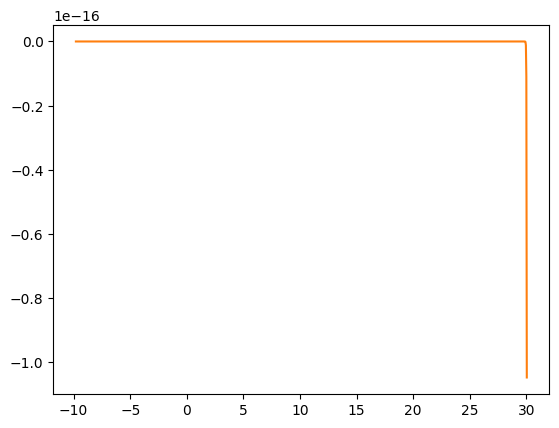

Iteration, E = 5 -18.649289772727276


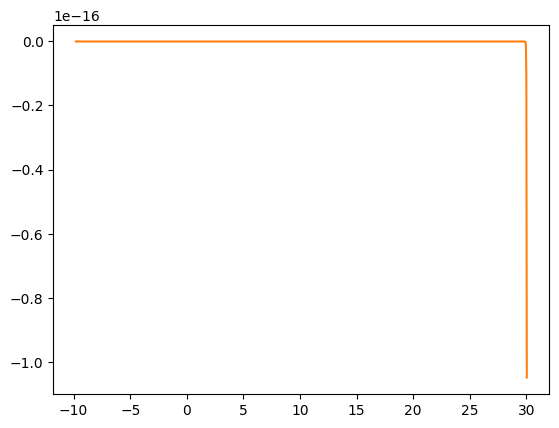

Iteration, E = 6 -18.674644886363637


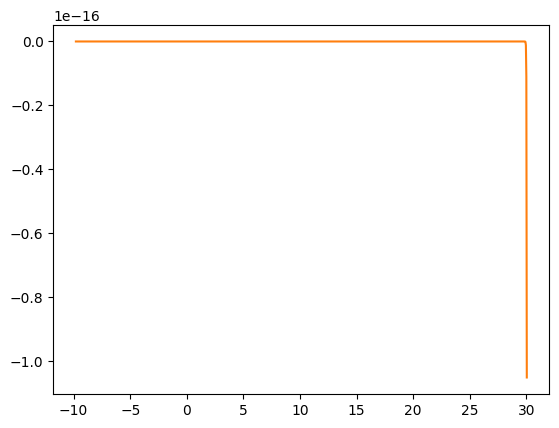

Iteration, E = 7 -18.68732244318182


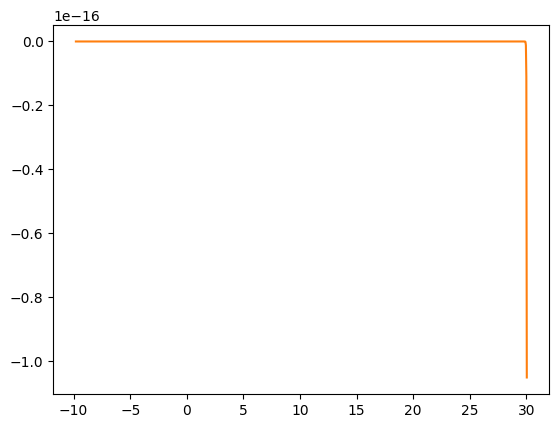

Iteration, E = 8 -18.69366122159091


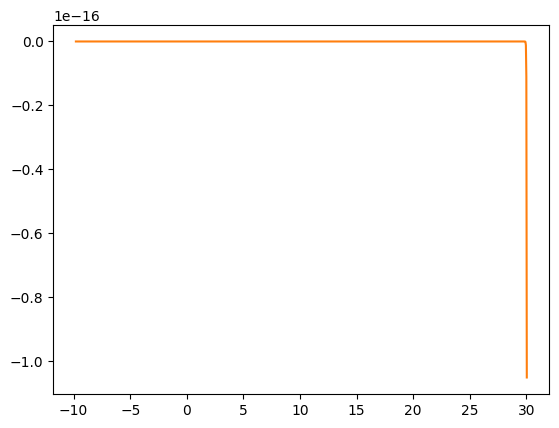

Iteration, E = 9 -18.69683061079546


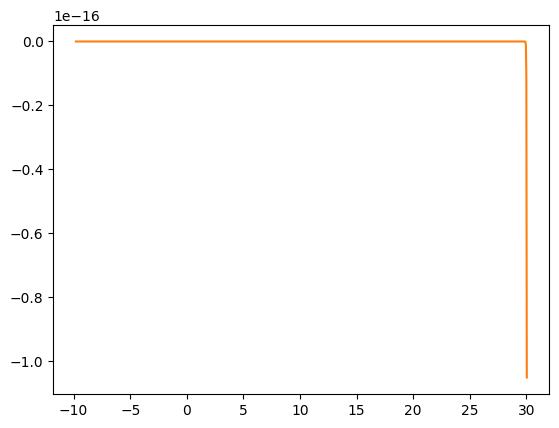

Iteration, E = 10 -18.69841530539773


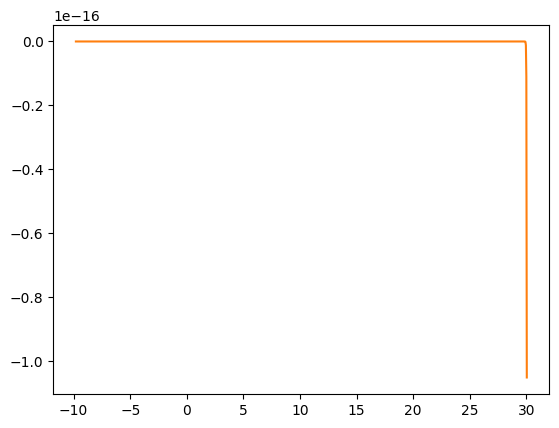

Iteration, E = 11 -18.699207652698867


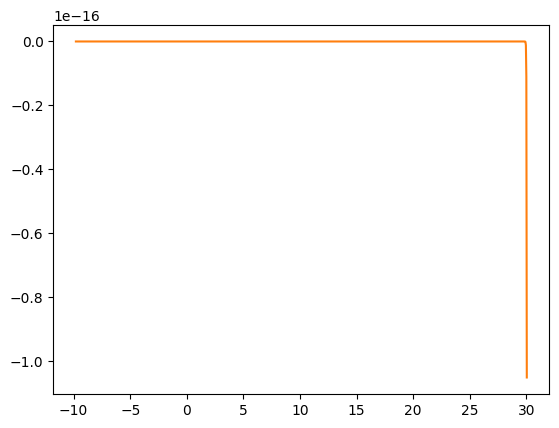

Iteration, E = 12 -18.699603826349435


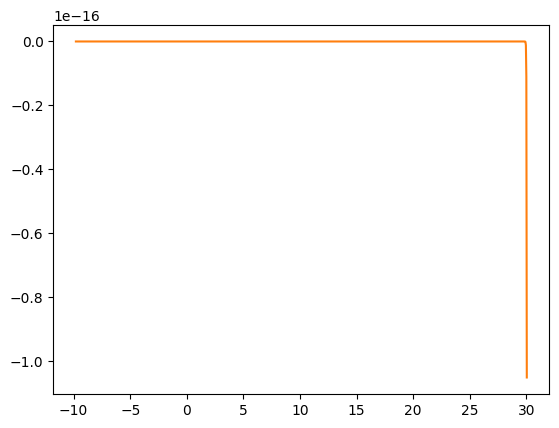

Iteration, E = 13 -18.699801913174717


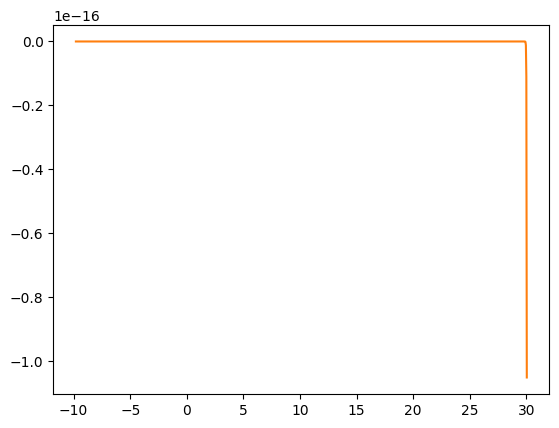

KeyboardInterrupt: 

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.grid()

for count in range(0, Nmax):

    E = (Emax + Emin) / 2

    Diff = diff(h, E)

    Etemp = E
    E = Emax
    diffMax = diff(h, E)
    E = Etemp

    if diffMax * Diff > 0:
        Emax = E
    else:
        Emin = E
    print('Iteration, E =', count, E)

    if abs(Diff) < eps:
        break
    if count > 3:
        fig.clear()

        plot(h)

        plt.plot(xL, Lwf)
        plt.plot(xR, Rwf)

        plt.text(3, -200, 'Energy = %10.4f' % E, fontsize = 14)

        plt.pause(0.8)

plt.xlabel('x')
plt.ylabel(r'$\psi(x)', fontsize = 18)
plt.title('R & L Wavefunctions Matched at x = 0')

print('Final Eigenvalue E =', E)
print('Iterations = ', count, 'max = ', max)

plt.show()